Iniciamos com as importações e as definições padrão. 

Fazemos também a leitura do nosso arquivo de dados e do nosso dicionário.

In [183]:
import pandas as pd
import numpy as np
from pathlib import Path
import pca
import matplotlib.pyplot as plt
import unicodedata

def remove_accents(input_str):
    # Normalize the string to decomposed form (NFD)
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    # Filter out characters categorized as 'Mn' (Non-spacing Marks / accents)
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)])

In [184]:


arq_original = 'WDICSV.csv'
arq_preparado = 'WDICSV_preparado.csv'
dicionario = 'WDISeries.csv'
paises = 'WDICountry.csv'

features_de_interesse = []
#Anos analisados pelo grupo 1
anos_g1 = ['2014', '2015', '2016', '2017','2018']
#Anos analisados pelo grupo 2
anos_g2 = ['2019', '2020', '2021', '2022','2023']
#Arquivo de dados
data = pd.read_csv(arq_original) 
#Contém informações sobre as features do dataset original
series_dict = pd.read_csv(dicionario)
# Informações sobre os países
paises_dict = pd.read_csv(paises)
paises_dict['Table Name'] = paises_dict['Table Name'].apply(remove_accents)
paises_dict = paises_dict.set_index(['Country Code', 'Table Name'])

# A forma desse dicionário nos diz quantas features podem existir para cada país.
print(series_dict.shape)

(1486, 20)


Podemos visualizar a estrutura básica do dataset escolhendo apenas algumas colunas. Esta fonte nos traz várias séries temporais: cada país possui múltiplos indiciadores, apresentados sob a coluna **Indicator Name**. As colunas adicionais trazem os valores para cada ano com informações no dataset.

In [185]:
print(data.iloc[:5,[0,2,-5,-4,-3]])

                  Country Name  \
0  Africa Eastern and Southern   
1  Africa Eastern and Southern   
2  Africa Eastern and Southern   
3  Africa Eastern and Southern   
4  Africa Eastern and Southern   

                                      Indicator Name       2021       2022  \
0  Access to clean fuels and technologies for coo...  21.419621  21.996456   
1  Access to clean fuels and technologies for coo...   9.480804   9.903209   
2  Access to clean fuels and technologies for coo...  40.723805  41.026351   
3            Access to electricity (% of population)  48.127211  48.801258   
4  Access to electricity, rural (% of rural popul...  32.709837  33.747222   

        2023  
0  22.541440  
1  10.288154  
2  41.289974  
3  50.667516  
4  35.240236  


Esse formato é ideal para realizarmos análises de séries temporais de indicadores específicos, ou de países específicos. Porém, a análise de séries temporais é uma disciplina complexa, que exige conhecimento e técnicas específicas. Além disso, se queremos agrupar países com base em indicadores e períodos específicos, essa estrutura dificultaria a aplicação de técnicas de redução de dimensionalidade. 

Poderíamos transformar essa estrutura em um modelo mais fácil de trabalhar se aplicamos o pivotamento da tabela. Nessa operação, transformamos cada indicador em uma coluna, fazendo com que cada país apresente uma única linha com os valores de cada indicador avaliado. Para os valores, devemos escolher uma forma de representar os dados desejados nessas linhas. Um exemplo de como fazer isso é selecionar o valor médio dos indicadores em um determinado período: 

In [186]:
def pivota_dataset(data:pd.DataFrame)->pd.DataFrame:
    #Posso gerar algum viés, ou problema se aplicar essa técnica de cálculo da média antes da limpeza dos dados?
    data['Mean'] = data[anos_g2].mean(axis=1) #axis 1 pois quero média das colunas e não das linhas
    # Transformo os indicadores em colunas, com a média do período sendo o valor
    # Meu índice usa as colunas Code e Name para manter ambas no dataframe resultante dessa operação
    pivoted = data.pivot(index=['Country Code','Country Name'],columns='Indicator Name',values='Mean')
    pivoted.reset_index()
    return pivoted

Se aplicamos essa função ao nosso dataset, temos uma estrutura colunar onde podemos avaliar a média dos dados em um determinado período. Porém, ainda existem algumas operações adicionais que podemos aplicar antes dessa função.

O dataset apresenta mais de **1400** indicadores para os países. É muito difícil extrair uma análise apropriada desse volume de dados. Felizmente, possuímos um dicionário de dados que classifica estes indicadores em algumas categorias:

In [187]:
print(len(series_dict['Topic'].unique()))

87


Podemos utilizar essas categorias para buscar indicadores coerentes com nossa necessidade de análise. Para isso, precisamos vasculhar o conjunto de indicadores neste dicionário e atualizar nosso conjunto de *features* de interesse. Por exemplo, podemos extrair dados do uso de eletricidade, percentual de pessoas usando a internet e o Produto Interno Bruto:

In [188]:
features_de_interesse = ['Electric power consumption (kWh per capita)', # Uso de eletricidade per capta (KWpc)
                         'Individuals using the Internet (% of population)',    # Pessoas usando a internet (%)
                         'GDP (current US$)', # PIB (U$)
                         'Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population)', # Pessoas abaixo da linha da pobreza
                         'Number of under-five deaths',
                         'Maternal mortality ratio (national estimate, per 100,000 live births)'
                         ]

data_reduzida = data[data['Indicator Name'].isin(features_de_interesse)].copy()
print(data_reduzida.iloc[:len(features_de_interesse),[0,2,-5,-4,-3]])

                     Country Name  \
378   Africa Eastern and Southern   
509   Africa Eastern and Southern   
658   Africa Eastern and Southern   
784   Africa Eastern and Southern   
992   Africa Eastern and Southern   
1128  Africa Eastern and Southern   

                                         Indicator Name          2021  \
378         Electric power consumption (kWh per capita)  5.134653e+02   
509                                   GDP (current US$)  1.114145e+12   
658    Individuals using the Internet (% of population)  2.500000e+01   
784   Maternal mortality ratio (national estimate, p...           NaN   
992                         Number of under-five deaths  1.470713e+06   
1128  Poverty headcount ratio at $8.30 a day (2021 P...           NaN   

              2022          2023  
378   5.027139e+02  4.840044e+02  
509   1.228968e+12  1.179359e+12  
658   2.680000e+01  2.780000e+01  
784            NaN           NaN  
992   1.498719e+06  1.428676e+06  
1128           NaN

Podemos agora pivotar nosso dataset para reduzir o número de colunas. Como não realizamos nenhuma operação de limpeza dos dados brutos, é provável que esse resultado apresente ausência de dados

In [189]:
data_pivotada = pivota_dataset(data_reduzida).copy()
ausentes = data_pivotada.isna().mean() * 100
print(ausentes.sort_values(ascending=False))

Indicator Name
Maternal mortality ratio (national estimate, per 100,000 live births)    74.436090
Poverty headcount ratio at $8.30 a day (2021 PPP) (% of population)      47.744361
Electric power consumption (kWh per capita)                              27.443609
Individuals using the Internet (% of population)                         16.165414
Number of under-five deaths                                               8.270677
GDP (current US$)                                                         2.631579
dtype: float64


Se consideramos o resultado dessa verificação, mais de 27% dos países não possuem dados para o indicador de consumo de eletricidade e mais de 74% dos países não apresentam dados para a taxa de mortalidade materna. Faz sentido manter um indicador que apresenta mais de 70% de dados faltantes?
Nesse caso temos 3 alternativas:
1. Remover indicadores, ou substituí-los por indicadores similares com percentual de ausência menor;
2. Remover os países sem estes indicadores de nossa análise;
3. Preencher estes valores com dados sintéticos.

Existem prós e contras para cada uma dessas alternativas. Para simplificar este exemplo, seguiremos com a imputação de valores sintéticos para este dataset, usando uma mediana simples. Uma alternativa interessante aqui é perceber que existem grupos de países neste dataset (Africa Eastern and Southern, Sub-Saharan Africa, etc). Nossa substituição de valores poderia verificar se existem dados deste identificador no grupo do país cujo dado está faltante.

In [190]:
#Removendo linha que não representa um país
data_pivotada = data_pivotada.drop(('INX', 'Not classified'))
#Podemos remover também as linhas que representam regiões
regioes = paises_dict[(paises_dict['Region']=='') | (paises_dict['Region'].isna())]
#Como os índices são os mesmos (Tuple Code + Name), podemos filtrar diretamente
data_pivotada = data_pivotada[~data_pivotada.index.isin(regioes.index)]

for feat in features_de_interesse:
    data_pivotada = data_pivotada.fillna({feat:data_pivotada[feat].median()})

In [191]:
##Ajuste de nomenclaturas para poder colorir o gráfico de acordo com a região
mapeamento = {
    ('VIR', 'Virgin Islands (U.S.)'): ('VIR', 'Virgin Islands (US)'),
    ('TEA', 'East Asia & Pacific (IDA & IBRD countries)'): ('TEA', 'East Asia & Pacific (IDA & IBRD)'),
    ('TEC', 'Europe & Central Asia (IDA & IBRD countries)'): ('TEC', 'Europe & Central Asia (IDA & IBRD)'),
    ('TLA', 'Latin America & the Caribbean (IDA & IBRD countries)'): ('TLA', 'Latin America & Caribbean (IDA & IBRD)'),
    ('TSS', 'Sub-Saharan Africa (IDA & IBRD countries)'): ('TSS', 'Sub-Saharan Africa (IDA & IBRD)')
}
data_pivotada.index = pd.MultiIndex.from_tuples(
    [mapeamento.get(idx, idx) for idx in data_pivotada.index],
    names=data_pivotada.index.names
)

C:\Users\eric.zancanaro\AppData\Local\Temp\ipykernel_11352\1111074609.py:19: UserWarning: Mismatched number of handles and labels: len(handles) = 8 len(labels) = 7
  plt.legend(handles=scatter.legend_elements()[0],
c:\Users\eric.zancanaro\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\text.py:1475: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(x))
c:\Users\eric.zancanaro\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))


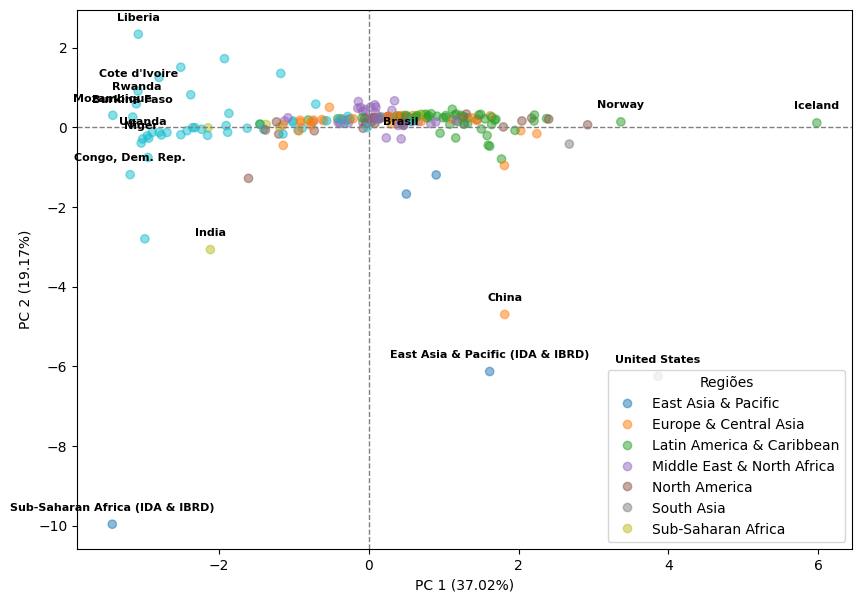

In [201]:
data_pivotada = (data_pivotada - data_pivotada.mean()) / data_pivotada.std()
componentes, var_explicada = pca.pca_svd(data_pivotada)

data_pca = pca.aplica_pca(data_pivotada, componentes, 2)
# Considero outliers os países em qualquer eixo (3 porque apliquei z-score mais cedo)
outliers = data_pca[(data_pca[0] > 3) | (data_pca[1] > 3) | 
                    ( (data_pca[0] < -3) | (data_pca[1] < -3))]
brasil = data_pca.loc['BRA']

# Visualização do gráfico
regioes_categorias = paises_dict.loc[data_pca.index, 'Region'].astype('category').cat
cores_categorias = regioes_categorias.codes
nomes_categorias = regioes_categorias.categories # Guarda os nomes: ['Africa', 'Europe'...]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(data_pca[0], data_pca[1], alpha=0.5, c=cores_categorias, cmap='tab10')
plt.xlabel(f"PC 1 ({var_explicada[0]:.2%})")
plt.ylabel(f"PC 2 ({var_explicada[1]:.2%})")
plt.legend(handles=scatter.legend_elements()[0], 
           labels=list(nomes_categorias), 
           title="Regiões",)
# Iterando sobre os outliers
for index, row in outliers.iterrows():
    # index é uma tupla (Country Code, Country Name)
    # Vamos usar o Country Name (primeiro elemento da tupla) para o label
    label = index[1] 
    plt.annotate(label, 
                 (row[0], row[1]),               # Coordenadas do ponto (PC1, PC2)
                 textcoords="offset points",    # Posicionamento relativo
                 xytext=(0, 10),                # 10 pontos acima do ponto
                 ha='center',                   # Alinhamento horizontal
                 fontsize=8,                    # Ajuste de fonte para não poluir
                 fontweight='bold')
plt.annotate('Brasil',(brasil[0],brasil[1]),
                textcoords="offset points",    # Posicionamento relativo
                xytext=(0, 10),                # 10 pontos acima do ponto
                ha='center',                   # Alinhamento horizontal
                fontsize=8,                    # Ajuste de fonte para não poluir
                fontweight='bold')

plt.axhline(0, color='grey', lw=1, ls='--') # Linha de referência Y
plt.axvline(0, color='grey', lw=1, ls='--') # Linha de referência X
plt.show()

In [200]:
# Primeiro componente principal é a primeira coluna
cp1 = componentes[:, 0] 
# Segundo componente principal é a segunda coluna
cp2 = componentes[:, 1] 

# Me diz o quanto cada unidade impacta no componente
importancia_absoluta_cp1 = np.abs(cp1)
importancia_absoluta_cp2 = np.abs(cp2)

cols = data_pivotada.columns

df_importancia = pd.DataFrame({
    'Feature Original': cols,
    'Peso Real (Loading)': cp1,
    'Importância Absoluta': importancia_absoluta_cp1 
})

df_importancia = df_importancia.sort_values(by='Importância Absoluta', ascending=False)

df_importancia2 = pd.DataFrame({
    'Feature Original': cols,
    'Peso Real (Loading)': cp2,
    'Importância Absoluta': importancia_absoluta_cp2 
})

df_importancia2 = df_importancia2.sort_values(by='Importância Absoluta', ascending=False)
print(df_importancia)
print(df_importancia2)

                                    Feature Original  Peso Real (Loading)  \
2   Individuals using the Internet (% of population)             0.596862   
5  Poverty headcount ratio at $8.30 a day (2021 P...            -0.544227   
0        Electric power consumption (kWh per capita)             0.464336   
3  Maternal mortality ratio (national estimate, p...            -0.260371   
4                        Number of under-five deaths            -0.184616   
1                                  GDP (current US$)             0.173461   

   Importância Absoluta  
2              0.596862  
5              0.544227  
0              0.464336  
3              0.260371  
4              0.184616  
1              0.173461  
                                    Feature Original  Peso Real (Loading)  \
4                        Number of under-five deaths            -0.697011   
1                                  GDP (current US$)            -0.657238   
3  Maternal mortality ratio (national estimate,

In [194]:
print(componentes.shape)

(6, 6)


Nesse caso, utilizamos apenas 2 componentes principais porque desejamos uma visualização bidimensional. Quanta informação esses componentes codificam?

A resposta dessa pergunta equivale a responder quanto da variância dos dados é preservada quando utilizamos 2 componentes principais. Esse dado é uma consequência do nosso cálculo de PCA e denominado de variância explicada: 

In [195]:
print(f"CP1:{var_explicada[0]}, CP2:{var_explicada[1]}, Soma:{var_explicada[0]+var_explicada[1]}")

CP1:0.3701531860675874, CP2:0.19165340676581707, Soma:0.5618065928334045


O conjunto dos 2 componentes principais mantém aproximadamente 60% da variância dos dados. Se nossa intenção fosse aplicar este conjunto de dados pós redução de dimensionalidade em um modelo de classificação, essa taxa poderia ser insuficiente para codificar todas as classes dos dados. Nesse caso, precisaríamos selecionar um número maior de componentes principais, cuja variância acumulada represente um valor adequado para nosso propósito.

Como podemos determinar se a adição de um componente principal extra seria benéfico para nossa análise? 

Uma forma usual de apresentar essa informação é com um gráfico de scree: 

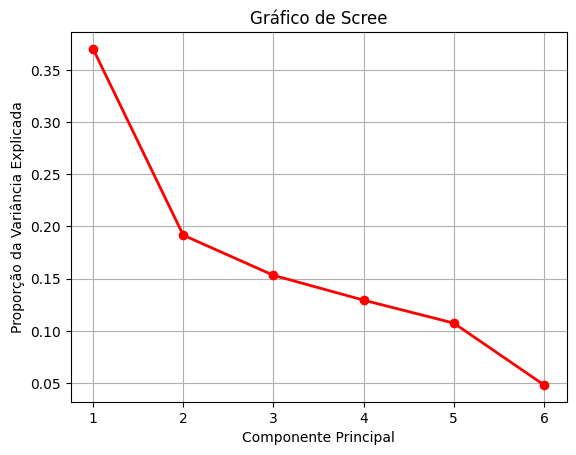

In [196]:
plt.figure()
plt.plot(np.arange(1, len(var_explicada) + 1), var_explicada, 'ro-', linewidth=2)
plt.title('Gráfico de Scree')
plt.xlabel('Componente Principal')
plt.ylabel('Proporção da Variância Explicada')
plt.grid(True)
plt.show()